<a href="https://colab.research.google.com/github/JulianaOlivatti/Atividade_em_Grupo/blob/main/aula_13_08_case_incidentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# bibliotecas padrões para um analista de dados
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url_base_dados ='https://docs.google.com/spreadsheets/d/e/2PACX-1vSBvDSgi4hK5bdmeHNfdhyJey0J_W3K-Z9l17wnaFn1MDBzN1jy1dG25_6Qn9nBO5JbPX1nPkG_qlqu/pub?gid=963299908&single=true&output=csv'
df_incidente = pd.read_csv(url_base_dados)

Sobre incidentes

In [30]:
df_incidente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Cliente                100 non-null    object 
 1   Nome                      100 non-null    object 
 2   Email                     100 non-null    object 
 3   Data_Compra               100 non-null    object 
 4   Produto_Comprado          100 non-null    object 
 5   Preco_Unitario            95 non-null     float64
 6   Qtd_Itens                 100 non-null    int64  
 7   Avaliacao_Experiencia     100 non-null    object 
 8   Comentarios_Qualitativos  84 non-null     object 
 9   Localizacao_Loja          100 non-null    object 
 10  Status_Venda              100 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 8.7+ KB


In [31]:
df_incidente.describe()

,Preco_Unitario,Qtd_Itens
count,95.000000,100.000000
mean,80.166842,2.890000
std,52.446118,1.362521
min,12.000000,1.000000
25%,45.500000,2.000000
50%,55.000000,3.000000
75%,85.000000,4.000000
max,199.990000,5.000000


In [32]:
df_incidente.describe(include='object')

,ID_Cliente,Nome,Email,Data_Compra,Produto_Comprado,Avaliacao_Experiencia,Comentarios_Qualitativos,Localizacao_Loja,Status_Venda
count,100,100,100,100,100,100,84,100,100
unique,100,72,72,86,10,5,14,5,4
top,CLI-1001,João Gomes,joão.gomes@exemplo.com,2026-05-09,Sensor IoT - Monitoramento Ambiental,Bom,Atendeu as expectativas.,Online,Concluída
freq,1,4,4,3,17,27,10,33,60


ETL

In [33]:
# encontrar as linhas dos Preco_Unitario vazios
dados_preco_vazio = df_incidente[df_incidente['Preco_Unitario'].isnull()]
display(dados_preco_vazio)

,ID_Cliente,Nome,Email,Data_Compra,Produto_Comprado,Preco_Unitario,Qtd_Itens,Avaliacao_Experiencia,Comentarios_Qualitativos,Localizacao_Loja,Status_Venda
12,CLI-1013,João Souza,joão.souza@exemplo.com,2026-01-29,Graphic Novel: O Cavaleiro das Trevas,NaN,2,Regular,Faltou clareza em alguns tópicos.,Online,Cancelada
57,CLI-1058,Juliana Gomes,juliana.gomes@exemplo.com,2026-06-14,Curso: Redes Convergentes,NaN,1,Bom,Tudo certo.,Online,Cancelada
63,CLI-1064,Maria Gomes,maria.gomes@exemplo.com,2026-02-24,Graphic Novel: Watchmen,NaN,3,Fraco,O pacote veio um pouco amassado.,Iguape,Devolvida
89,CLI-1090,Juliana Carvalho,juliana.carvalho@exemplo.com,2026-02-11,Curso: Redes Convergentes,NaN,1,Excelente,"Chegou muito rápido, ótimo produto.",Online,Cancelada
97,CLI-1098,Mariana Silva,mariana.silva@exemplo.com,2026-04-18,Faixa Jiu-Jitsu (Branca),NaN,3,Bom,"Produto ok, condiz com o preço.",Indaiatuba,Devolvida


Excluir dados

In [34]:
df_incidente_excluidos = df_incidente.dropna(subset=['Preco_Unitario'])
#df.dropna(subset=['NOME DA COLUNA QUE QUER EXCLUIR DADOS VAZIOS'])
display(df_incidente_excluidos.head(20))

,ID_Cliente,Nome,Email,Data_Compra,Produto_Comprado,Preco_Unitario,Qtd_Itens,Avaliacao_Experiencia,Comentarios_Qualitativos,Localizacao_Loja,Status_Venda
0,CLI-1001,Luiza Lima,luiza.lima@exemplo.com,2026-03-17,Curso: Segurança da Informação,199.99,4,Bom,Atendeu as expectativas.,Online,Concluída
1,CLI-1002,Juliana Oliveira,juliana.oliveira@exemplo.com,2026-07-17,Kimono Jiu-Jitsu Trançado,150.00,5,Excelente,"Didática incrível no material, ajudou muito.",Campinas,Concluída
2,CLI-1003,Juliana Oliveira,juliana.oliveira@exemplo.com,2026-08-01,Sensor IoT - Monitoramento Ambiental,85.00,5,Excelente,"Didática incrível no material, ajudou muito.",Iguape,Concluída
3,CLI-1004,Fernando Alves,fernando.alves@exemplo.com,2026-03-20,Sensor IoT - Monitoramento Ambiental,85.00,3,Bom,Atendeu as expectativas.,Indaiatuba,Cancelada
4,CLI-1005,Ana Alves,ana.alves@exemplo.com,2026-07-07,Graphic Novel: Watchmen,45.50,4,Excelente,Funcionou perfeitamente no meu projeto.,Online,Concluída
5,CLI-1006,Fernanda Carvalho,fernanda.carvalho@exemplo.com,2026-02-28,Curso: Redes Convergentes,149.99,3,Fraco,Atrasou a entrega em 3 dias.,São Paulo,Devolvida
6,CLI-1007,Juliana Alves,juliana.alves@exemplo.com,2026-05-09,Graphic Novel: O Cavaleiro das Trevas,45.50,2,Regular,O pacote veio um pouco amassado.,Indaiatuba,Concluída
7,CLI-1008,João Gomes,joão.gomes@exemplo.com,2026-01-23,Graphic Novel: O Cavaleiro das Trevas,45.50,3,Excelente,"Leitura obrigatória, visão fantástica.",Iguape,Devolvida
8,CLI-1009,Fernanda Alves,fernanda.alves@exemplo.com,2026-02-20,Faixa Jiu-Jitsu (Branca),12.00,3,Bom,Atendeu as expectativas.,São Paulo,Devolvida
9,CLI-1010,Luiza Oliveira,luiza.oliveira@exemplo.com,2026-04-23,Sensor IoT - Monitoramento Ambiental,85.00,4,Excelente,"Didática incrível no material, ajudou muito.",Iguape,Concluída


Substituir valores pela média ou mediana geral

In [35]:
media_precos_geral = df_incidente['Preco_Unitario'].mean()

# vamos inserir o valor de média na base de dados
df_incidente_media = df_incidente.copy()
# para inserir um novo valor, devo chamar o campo que eu quero
# a base recebe ela mesma, mas com o que que quero substituir
df_incidente_media["preco_Unitario"] = df_incidente_media["Preco_Unitario"].fillna((media_precos_geral))
# fillna filtra tudo o que é vazio e subistitui e pelo valor informado no ()
display(df_incidente_media.head(15))

,ID_Cliente,Nome,Email,Data_Compra,Produto_Comprado,Preco_Unitario,Qtd_Itens,Avaliacao_Experiencia,Comentarios_Qualitativos,Localizacao_Loja,Status_Venda,preco_Unitario
0,CLI-1001,Luiza Lima,luiza.lima@exemplo.com,2026-03-17,Curso: Segurança da Informação,199.99,4,Bom,Atendeu as expectativas.,Online,Concluída,199.990000
1,CLI-1002,Juliana Oliveira,juliana.oliveira@exemplo.com,2026-07-17,Kimono Jiu-Jitsu Trançado,150.00,5,Excelente,"Didática incrível no material, ajudou muito.",Campinas,Concluída,150.000000
2,CLI-1003,Juliana Oliveira,juliana.oliveira@exemplo.com,2026-08-01,Sensor IoT - Monitoramento Ambiental,85.00,5,Excelente,"Didática incrível no material, ajudou muito.",Iguape,Concluída,85.000000
3,CLI-1004,Fernando Alves,fernando.alves@exemplo.com,2026-03-20,Sensor IoT - Monitoramento Ambiental,85.00,3,Bom,Atendeu as expectativas.,Indaiatuba,Cancelada,85.000000
4,CLI-1005,Ana Alves,ana.alves@exemplo.com,2026-07-07,Graphic Novel: Watchmen,45.50,4,Excelente,Funcionou perfeitamente no meu projeto.,Online,Concluída,45.500000
5,CLI-1006,Fernanda Carvalho,fernanda.carvalho@exemplo.com,2026-02-28,Curso: Redes Convergentes,149.99,3,Fraco,Atrasou a entrega em 3 dias.,São Paulo,Devolvida,149.990000
6,CLI-1007,Juliana Alves,juliana.alves@exemplo.com,2026-05-09,Graphic Novel: O Cavaleiro das Trevas,45.50,2,Regular,O pacote veio um pouco amassado.,Indaiatuba,Concluída,45.500000
7,CLI-1008,João Gomes,joão.gomes@exemplo.com,2026-01-23,Graphic Novel: O Cavaleiro das Trevas,45.50,3,Excelente,"Leitura obrigatória, visão fantástica.",Iguape,Devolvida,45.500000
8,CLI-1009,Fernanda Alves,fernanda.alves@exemplo.com,2026-02-20,Faixa Jiu-Jitsu (Branca),12.00,3,Bom,Atendeu as expectativas.,São Paulo,Devolvida,12.000000
9,CLI-1010,Luiza Oliveira,luiza.oliveira@exemplo.com,2026-04-23,Sensor IoT - Monitoramento Ambiental,85.00,4,Excelente,"Didática incrível no material, ajudou muito.",Iguape,Concluída,85.000000


Substituir apenas com a média do produto escolhido

In [36]:
# Vaos mostrar para o sistema apenas o produto escolhido
display(df_incidente[df_incidente["Produto_Comprado"] == "Graphic Novel: O Cavaleiro das Trevas"])

,ID_Cliente,Nome,Email,Data_Compra,Produto_Comprado,Preco_Unitario,Qtd_Itens,Avaliacao_Experiencia,Comentarios_Qualitativos,Localizacao_Loja,Status_Venda
6,CLI-1007,Juliana Alves,juliana.alves@exemplo.com,2026-05-09,Graphic Novel: O Cavaleiro das Trevas,45.5,2,Regular,O pacote veio um pouco amassado.,Indaiatuba,Concluída
7,CLI-1008,João Gomes,joão.gomes@exemplo.com,2026-01-23,Graphic Novel: O Cavaleiro das Trevas,45.5,3,Excelente,"Leitura obrigatória, visão fantástica.",Iguape,Devolvida
12,CLI-1013,João Souza,joão.souza@exemplo.com,2026-01-29,Graphic Novel: O Cavaleiro das Trevas,NaN,2,Regular,Faltou clareza em alguns tópicos.,Online,Cancelada
20,CLI-1021,Eduardo Lima,eduardo.lima@exemplo.com,2026-06-21,Graphic Novel: O Cavaleiro das Trevas,45.5,1,Bom,NaN,São Paulo,Cancelada
49,CLI-1050,Lucas Carvalho,lucas.carvalho@exemplo.com,2026-07-04,Graphic Novel: O Cavaleiro das Trevas,45.5,2,Bom,"Produto ok, condiz com o preço.",Campinas,Cancelada
51,CLI-1052,Rodrigo Oliveira,rodrigo.oliveira@exemplo.com,2026-02-22,Graphic Novel: O Cavaleiro das Trevas,45.5,2,Excelente,"Excelente material, recomendo demais!",Campinas,Cancelada
55,CLI-1056,Fernando Gomes,fernando.gomes@exemplo.com,2026-04-05,Graphic Novel: O Cavaleiro das Trevas,45.5,2,Excelente,"Didática incrível no material, ajudou muito.",Campinas,Concluída
58,CLI-1059,Eduardo Oliveira,eduardo.oliveira@exemplo.com,2026-02-19,Graphic Novel: O Cavaleiro das Trevas,45.5,4,Fraco,O tamanho não serviu direito.,Online,Concluída
68,CLI-1069,Pedro Lima,pedro.lima@exemplo.com,2026-06-05,Graphic Novel: O Cavaleiro das Trevas,45.5,4,Muito bom,"Excelente material, recomendo demais!",Online,Concluída
84,CLI-1085,João Costa,joão.costa@exemplo.com,2026-04-01,Graphic Novel: O Cavaleiro das Trevas,45.5,5,Bom,NaN,Iguape,Concluída


In [37]:
media_produto_escolhido = df_incidente[df_incidente["Produto_Comprado"] == "Graphic Novel: O Cavaleiro das Trevas"]["Preco_Unitario"].mean()
print(media_produto_escolhido)

45.5


In [40]:
# vamos inserir a média dos produtos na tabela
df_incidente['Preco_Unitario'] = df_incidente['Preco_Unitario'].fillna(
    df_incidente.groupby('Produto_Comprado')['Preco_Unitario'].transform('mean')
)

display(df_incidente.head(60))

,ID_Cliente,Nome,Email,Data_Compra,Produto_Comprado,Preco_Unitario,Qtd_Itens,Avaliacao_Experiencia,Comentarios_Qualitativos,Localizacao_Loja,Status_Venda
0,CLI-1001,Luiza Lima,luiza.lima@exemplo.com,2026-03-17,Curso: Segurança da Informação,199.99,4,Bom,Atendeu as expectativas.,Online,Concluída
1,CLI-1002,Juliana Oliveira,juliana.oliveira@exemplo.com,2026-07-17,Kimono Jiu-Jitsu Trançado,150.00,5,Excelente,"Didática incrível no material, ajudou muito.",Campinas,Concluída
2,CLI-1003,Juliana Oliveira,juliana.oliveira@exemplo.com,2026-08-01,Sensor IoT - Monitoramento Ambiental,85.00,5,Excelente,"Didática incrível no material, ajudou muito.",Iguape,Concluída
3,CLI-1004,Fernando Alves,fernando.alves@exemplo.com,2026-03-20,Sensor IoT - Monitoramento Ambiental,85.00,3,Bom,Atendeu as expectativas.,Indaiatuba,Cancelada
4,CLI-1005,Ana Alves,ana.alves@exemplo.com,2026-07-07,Graphic Novel: Watchmen,45.50,4,Excelente,Funcionou perfeitamente no meu projeto.,Online,Concluída
5,CLI-1006,Fernanda Carvalho,fernanda.carvalho@exemplo.com,2026-02-28,Curso: Redes Convergentes,149.99,3,Fraco,Atrasou a entrega em 3 dias.,São Paulo,Devolvida
6,CLI-1007,Juliana Alves,juliana.alves@exemplo.com,2026-05-09,Graphic Novel: O Cavaleiro das Trevas,45.50,2,Regular,O pacote veio um pouco amassado.,Indaiatuba,Concluída
7,CLI-1008,João Gomes,joão.gomes@exemplo.com,2026-01-23,Graphic Novel: O Cavaleiro das Trevas,45.50,3,Excelente,"Leitura obrigatória, visão fantástica.",Iguape,Devolvida
8,CLI-1009,Fernanda Alves,fernanda.alves@exemplo.com,2026-02-20,Faixa Jiu-Jitsu (Branca),12.00,3,Bom,Atendeu as expectativas.,São Paulo,Devolvida
9,CLI-1010,Luiza Oliveira,luiza.oliveira@exemplo.com,2026-04-23,Sensor IoT - Monitoramento Ambiental,85.00,4,Excelente,"Didática incrível no material, ajudou muito.",Iguape,Concluída


In [43]:
# Substituir dados @exemplo por @email
df_incidente["Email"] = df_incidente["Email"].str.replace("@exemplo", "@email")
display(df_incidente)

df_incidente.to_csv("dados_limpos.csv", index=False)

,ID_Cliente,Nome,Email,Data_Compra,Produto_Comprado,Preco_Unitario,Qtd_Itens,Avaliacao_Experiencia,Comentarios_Qualitativos,Localizacao_Loja,Status_Venda
0,CLI-1001,Luiza Lima,luiza.lima@email.com,2026-03-17,Curso: Segurança da Informação,199.99,4,Bom,Atendeu as expectativas.,Online,Concluída
1,CLI-1002,Juliana Oliveira,juliana.oliveira@email.com,2026-07-17,Kimono Jiu-Jitsu Trançado,150.00,5,Excelente,"Didática incrível no material, ajudou muito.",Campinas,Concluída
2,CLI-1003,Juliana Oliveira,juliana.oliveira@email.com,2026-08-01,Sensor IoT - Monitoramento Ambiental,85.00,5,Excelente,"Didática incrível no material, ajudou muito.",Iguape,Concluída
3,CLI-1004,Fernando Alves,fernando.alves@email.com,2026-03-20,Sensor IoT - Monitoramento Ambiental,85.00,3,Bom,Atendeu as expectativas.,Indaiatuba,Cancelada
4,CLI-1005,Ana Alves,ana.alves@email.com,2026-07-07,Graphic Novel: Watchmen,45.50,4,Excelente,Funcionou perfeitamente no meu projeto.,Online,Concluída
...,...,...,...,...,...,...,...,...,...,...,...
95,CLI-1096,Rafael Gomes,rafael.gomes@email.com,2026-02-15,Graphic Novel: O Cavaleiro das Trevas,45.50,2,Bom,Atendeu as expectativas.,São Paulo,Concluída
96,CLI-1097,Luiza Alves,luiza.alves@email.com,2026-05-17,Graphic Novel: Watchmen,45.50,4,Bom,"Produto ok, condiz com o preço.",Campinas,Concluída
97,CLI-1098,Mariana Silva,mariana.silva@email.com,2026-04-18,Faixa Jiu-Jitsu (Branca),12.00,3,Bom,"Produto ok, condiz com o preço.",Indaiatuba,Devolvida
98,CLI-1099,Rafael Carvalho,rafael.carvalho@email.com,2026-03-24,Faixa Jiu-Jitsu (Branca),12.00,4,Regular,Atrasou a entrega em 3 dias.,São Paulo,Concluída


Gráficos

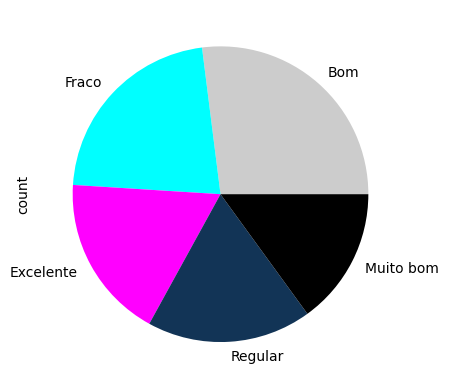

In [46]:
# Criação de graficos

Avaliacao_Experiencia = df_incidente['Avaliacao_Experiencia'].value_counts()

Avaliacao_Experiencia.plot(kind='pie',
                           colors=["#ccc","#00ffff","#ff00ff",'#123456',"#000"])
#bar - line - barh - box - hist - kde - area - pie - scatter
plt.show()